**Overview**

This notebook visualize different molecular structures and highlight most important functional groups in them

In [188]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from rdkit import Chem
from chemlib import Element
import torch
import torch.nn as nn
from torch_geometric.nn import GraphConv, GravNetConv, global_mean_pool, global_add_pool, global_max_pool, EdgePooling, EdgeConv, NNConv
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
import wandb
from torchmetrics import Accuracy, Recall, Precision, F1Score
device = 'cpu'
import pickle

from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig
import os

from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D, MolDraw2DCairo, MolDraw2DSVG
from IPython.display import SVG
from PIL import Image

In [148]:
abs_path = os.path.abspath('')
Data_df = pd.read_excel('Data.xlsx', sheet_name='Sheet1')
Data_df.drop(columns = ['Zero-shear viscosity'], inplace = True)

In [149]:
class Custom_dataset(Dataset):
    def __init__(self, X):
        super().__init__()
        self.X_df = X
    def get(self, idx):
        instance = self.X_df.iloc[idx, :]
        try:
            x = make_x(instance)
        except:
            print('Invalid mol - cannot make x')
        try:
            edge_index = make_edge_indices(instance)
        except:
            print('Invalid mol - cannot make edge indices')
        try:
            edge_attr = make_edge_features(instance)
        except:
            print('Invalid mol - cannot make edge attrs')
        data = Data(x = x, edge_index = edge_index, edge_attr = edge_attr)
        return data
    def len(self):
        return (len(self.X_df))

In [150]:
def make_edge_features(df_line):
    test_molecule = Chem.MolFromSmiles(df_line['SMILES'])
    #instantiate array with zeros that will be filled with ones where necessary
    edge_features = np.zeros([test_molecule.GetNumBonds(), 4])
    #iterating through bonds in molecule. 
    for i, bond in enumerate(test_molecule.GetBonds()):
        if bond.GetBondTypeAsDouble() == 1.0:
            edge_features[i,0] = 1
        elif bond.GetBondTypeAsDouble() == 2.0:
            edge_features[i,1] = 1
        elif bond.GetBondTypeAsDouble() == 3.0:
            edge_features[i, 2] = 1
        #there are no other types except aromatic - 4th position
        else:
            edge_features[i, 3] = 1
    return torch.tensor(edge_features, dtype = torch.float32)

In [151]:
def make_x(df_line):
    atom_properties = []
    mol = Chem.MolFromSmiles(df_line['SMILES'])
    for atom in mol.GetAtoms():
        _el = Element(atom.GetSymbol())
        atom_properties.append([atom.GetAtomicNum(), atom.GetMass(), int(atom.GetIsAromatic()), atom.GetExplicitValence(), 
                                atom.GetImplicitValence(), atom.GetTotalValence(), 
                                atom.GetNumExplicitHs(), atom.GetNumImplicitHs(), atom.GetTotalNumHs(),
                                atom.GetDegree(), atom.GetTotalDegree(), atom.GetFormalCharge(),
                               int(atom.IsInRing()), _el.Electronegativity, _el.FirstIonization, _el.AtomicRadius, _el.SpecificHeat, df_line['CTAB concentration (mM)'], df_line['Additive concentration'],
                                df_line['CTAB/additive'], df_line['Temperature']
                               ])
        x = torch.tensor(atom_properties, dtype = torch.float32)
    return x

In [152]:
def make_edge_indices(df_line):
    mol = Chem.MolFromSmiles(df_line['SMILES'])
    start_atoms = []
    end_atoms = []
    for bond in mol.GetBonds():
        start_atoms.append(bond.GetBeginAtomIdx())
        end_atoms.append(bond.GetEndAtomIdx())
    return torch.tensor([start_atoms, end_atoms], dtype = torch.int64)

In [153]:
class Graph_nn(nn.Module):
    def __init__(self, num_node_features = 21, n1 = 500, n2 = 500):
        super().__init__()
        self.nn_conv_1 = NNConv(in_channels = num_node_features, out_channels = n1, nn = nn.Sequential(nn.Linear(4, n1), nn.CELU(), nn.Linear(n1, 21*n1)))
        self.a_nn_conv1 = nn.CELU()
        
        self.edge_conv_3 = EdgeConv(nn = nn.Sequential(nn.Linear(2*n1, n2), nn.CELU(), nn.Linear(n2,n2)))
        self.a3 = nn.CELU()
        
        self.edgepool = EdgePooling(in_channels = n2,  dropout = 0.3) 
        self.linear_1 = nn.Linear(in_features = n2, out_features = 2)

        
    def forward(self, data):
        x, edge_index, edge_attr  = data.x, data.edge_index, data.edge_attr
        x = self.a_nn_conv1(self.nn_conv_1(x = x, edge_index = edge_index, edge_attr = edge_attr))
        x = self.a3(self.edge_conv_3(x = x, edge_index = edge_index))
       
        if data.batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        else:
            batch = data.batch
 
        x, new_edge_index, batch_assign, _ = self.edgepool(x = x, edge_index = edge_index, batch = batch)
        x = global_add_pool(x, batch = batch_assign)
        x = self.linear_1(x)
        return x

In [154]:
class Custom_dataset(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X_df = X
        self.y_series = y
    def get(self, idx):
        instance = self.X_df.iloc[idx, :]
        try:
            x = make_x(instance)
        except:
            print('Invalid mol - cannot make x')
        try:
            edge_index = make_edge_indices(instance)
        except:
            print('Invalid mol - cannot make edge indices')
        try:
            edge_attr = make_edge_features(instance)
        except:
            print('Invalid mol - cannot make edge attrs')

        
        y = torch.tensor(self.y_series.iloc[idx], dtype = torch.long)
        data = Data(x = x, edge_index = edge_index, edge_attr = edge_attr, y = y)
        return data
    def len(self):
        return (len(self.X_df))

In [155]:
with open('model_standard_acc.pickle', 'rb') as inp:
    model = pickle.load(inp)

Class "WrappedModel" was made to allow working with "Explainer" class in Pytorch Geometric

In [156]:
class WrappedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index, edge_attr, batch=None):
        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            batch=batch
        )
        return torch.softmax(self.model(data), dim = 1)

In [157]:
wrapped_model = WrappedModel(model).to(device)

Then we're working with different molecules

In [235]:
interesting_molecule = 441
smi = Data_df.loc[interesting_molecule, 'SMILES']
name = Data_df.loc[interesting_molecule, 'Trivial name']
mol = Chem.MolFromSmiles(smi)
print(name)

propofol


In [236]:
Ds = Custom_dataset(X = Data_df, y = Data_df['Is gel'])
data = Ds[interesting_molecule]
data.to(device)

Data(x=[13, 21], edge_index=[2, 13], edge_attr=[13, 4], y=1)

In [237]:
explainer = Explainer(model = wrapped_model, algorithm = GNNExplainer(), explanation_type='model', model_config=ModelConfig(mode='binary_classification',task_level='graph', return_type='probs'), node_mask_type='object', edge_mask_type = 'object')

In [238]:
explanation = explainer(x = data.x, edge_index= data.edge_index, edge_attr = data.edge_attr)

In [239]:
node_mask = explanation.node_mask
edge_mask = explanation.edge_mask

In [240]:
node_mask_np = node_mask.numpy().squeeze()
edge_mask_np = edge_mask.numpy()

node_mask_np = (node_mask_np - np.min(node_mask_np))/(np.max(node_mask_np)-np.min(node_mask_np))
edge_mask_np = (edge_mask_np - np.min(edge_mask_np))/(np.max(edge_mask_np)-np.min(edge_mask_np))

In [241]:
drawer = rdMolDraw2D.MolDraw2DCairo(600, 600)

In [242]:
atom_colors = {}
for i, s in enumerate(node_mask_np):
    atom_colors[i] = (1, 1-s, 1-s)

bond_colors = {}
for i, s in enumerate(edge_mask_np):
    bond_colors[i] = (1, 1-s, 1-s)

In [243]:
atom_radii = {
    i: 0.2 + 0.5*v
    for i, v in enumerate(node_mask_np)
}

In [244]:
drawer.DrawMolecule(mol, highlightAtoms = list(atom_colors.keys()), highlightAtomColors = atom_colors, highlightAtomRadii = atom_radii, highlightBonds = list(bond_colors.keys()), highlightBondColors = bond_colors, legend = name)
drawer.FinishDrawing()
drawer.WriteDrawingText(name+'.png')

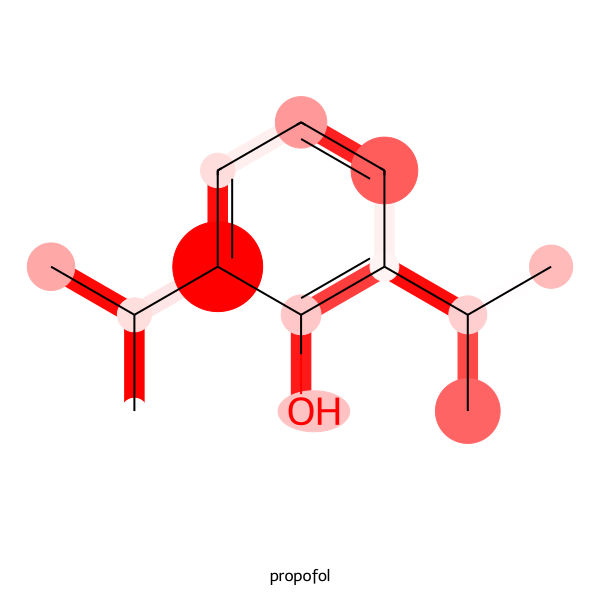

In [245]:
Image.open(name+'.png')